In [8]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import time
import os
from pathlib import Path


import sys
sys.path.append(str(Path.cwd().parent))
from parser_table import *
from elements.board import *
from elements.pieces import *

root = Path.cwd().parents[1]   # src/

sys.path.append(str(root / "ui"))

from virtual_board import LiveBoard



In [9]:
def get_energia(imagen):
    imagen = imagen.astype(np.float32)
    return np.mean(imagen**2)

In [10]:
def visualizar_rois(parser, imagen, mostrar_texto=True):

    y_pos = parser.y_pos
    x_pos = parser.x_pos

    # aseguramos formato consistente (BGR → RGB)
    if len(imagen.shape) == 3 and imagen.shape[2] == 3:
        img_rgb = cv2.cvtColor(imagen, cv2.COLOR_BGR2RGB)
    else:
        img_rgb = imagen.copy()

    fig, axs = plt.subplots(8, 8, figsize=(10, 10))

    for i in range(8):
        for j in range(8):

            x1, x2 = x_pos[j], x_pos[j + 1]
            y1, y2 = y_pos[i], y_pos[i + 1]

            roi = img_rgb[y1:y2, x1:x2]

            axs[i, j].imshow(roi, cmap='gray', vmin=0, vmax=255)

            if mostrar_texto:
                axs[i, j].set_title(f"{i},{j}", fontsize=8)

            axs[i, j].axis("off")

    plt.tight_layout()
    plt.show()

def aplicar_movimiento(tablero, top4):

    print("\nTurno actual:", tablero.turno)

    # -------------------------------------------------
    # 1. Separar candidatos según ocupación
    # -------------------------------------------------

    origenes = []
    destinos = []

    for i, j in top4:

        pieza = tablero.piezas[i][j]

        if pieza is None:
            destinos.append((i, j))
        else:
            # verificamos si es del jugador en turno
            if pieza.color == tablero.turno:
                origenes.append((i, j))
            else:
                # pieza enemiga → también puede ser destino (captura)
                destinos.append((i, j))

    print("\nOrígenes candidatos:", origenes)
    print("Destinos candidatos:", destinos)

    # -------------------------------------------------
    # 2. Validación mínima
    # -------------------------------------------------

    if not origenes or not destinos:
        print("No se pudo inferir movimiento")
        return

    # -------------------------------------------------
    # 3. Selección simple
    # -------------------------------------------------

    origen = origenes[0]
    destino = destinos[0]

    print("\nMovimiento inferido:")
    print("Origen:", origen)
    print("Destino:", destino)

    # -------------------------------------------------
    # 4. Ejecutar movimiento
    # -------------------------------------------------
    # Habría que revisar si esto asegura la validez del movimiento.

    tablero.mover(origen=origen, destino=destino)

    # -------------------------------------------------
    # 5. Estado final
    # -------------------------------------------------

    print("\nDespués del movimiento:")
    print(tablero.matriz)

    print("\nTurno:", tablero.turno)

def obtener_top(pre_ref, new_ref, umbral_pieza):

    parser = ParserTable(new_ref)

    parser.detect_board_corners()
    parser.correct_perspective()
    parser.standardize_orientation()
    parser.detect_grid_lines()

    y_pos = parser.y_pos
    x_pos = parser.x_pos

    # ─────────────────────────────────────────────
    # DIFERENCIA EN ESPACIO ORIGINAL
    # ─────────────────────────────────────────────
    diferencia = cv2.absdiff(new_ref, pre_ref)

    # ─────────────────────────────────────────────
    # DIFERENCIA EN ESPACIO DEL TABLERO
    # ─────────────────────────────────────────────
    diferencia_warp = parser.aplicar_warp(
        diferencia
    )

    # --------------------------------
    # Obtención de ROIs y sus energías
    # --------------------------------
    ENERGIAS = []
    ROIS = []
    for i in range(8):
        rois = []
        energias = []
        for j in range(8):

            x1, x2 = x_pos[j], x_pos[j + 1]
            y1, y2 = y_pos[i], y_pos[i + 1]

            roi = diferencia_warp[y1:y2, x1:x2]
            rois.append(roi)
        
            energias.append(get_energia(roi))
        ROIS.append(rois)
        ENERGIAS.append(energias)
    ENERGIAS = np.array(ENERGIAS)
    
    flat = ENERGIAS.ravel()

    mask = flat > umbral_pieza
    indices_validos = np.where(mask)[0]

    if len(indices_validos) == 0:
        top4 = []
    else:
        # ordenamos solo los válidos
        sorted_validos = indices_validos[np.argsort(flat[indices_validos])[::-1]]

        top4 = [
            (idx // 8, idx % 8)
            for idx in sorted_validos[:4]
        ]

    print(np.array(top4))

    # ─────────────────────────────────────────────
    # VISUALIZACIÓN
    # ─────────────────────────────────────────────
    vis = diferencia_warp.copy()
    visualizar_rois(parser, vis)

    # grilla Hough
    for x in x_pos:
        cv2.line(vis, (x, 0), (x, vis.shape[0]), (0, 255, 0), 2)

    for y in y_pos:
        cv2.line(vis, (0, y), (vis.shape[1], y), (0, 255, 0), 2)

    plt.figure(figsize=(6, 6))
    plt.imshow(vis, cmap='gray', vmin=0, vmax=255)
    plt.title("Diferencia warp + grilla (espacio tablero)")
    plt.axis("off")
    plt.show()
    return np.array(top4), ENERGIAS

In [11]:
def ver_por_frame(video, energias, interrupciones, referencias):

    upper_cap_slider_max = len(video) - 1

    title_frame = "Frame"
    title_ref = "Referencia"
    title_diff = "Diferencia"
    title_ref_diff = "Diff Referencias"

    def on_trackbar(x):

        frame = video[x].copy()

        gris = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

        frame_ref = referencias[x]
        if x > 0:

            ref_anterior = referencias[x - 1]

            diff_refs = cv2.absdiff(
                frame_ref,
                ref_anterior
            )

            energia_refs = get_energia(diff_refs)

        else:

            diff_refs = np.zeros_like(frame_ref)

            energia_refs = 0

        diff = cv2.absdiff(gris,frame_ref)

        energia = energias[x]
        interrupcion = interrupciones[x]

        cv2.putText(frame, f"Frame: {x}", (20, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 255, 0), 2)
        cv2.putText(frame, f"Energia: {energia:.2f}", (20, 65), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 255, 0), 2)
        cv2.putText(frame, f"Interrupcion: {interrupcion}", (20, 100), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 0, 255) if interrupcion else (0, 255, 0), 2)
        diff_refs_vis = diff_refs.copy()

        cv2.putText(
            diff_refs_vis,
            f"Energia: {energia_refs:.2f}",
            (20, 30),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.8,
            255,
            2
        )

        cv2.imshow(title_frame, frame)
        cv2.imshow(title_ref, frame_ref)
        cv2.imshow(title_diff, diff)
        cv2.imshow(title_ref_diff, diff_refs_vis)

    cv2.namedWindow(title_frame)
    cv2.namedWindow(title_ref)
    cv2.namedWindow(title_diff)
    cv2.namedWindow(title_ref_diff)

    cv2.createTrackbar("Frame", title_frame, 0, upper_cap_slider_max, on_trackbar)

    on_trackbar(0)

    cv2.waitKey()
    cv2.destroyAllWindows()


def ejecutar_foto_captura(vivo=True, url='../../../data/raw/prueba_bien.mp4', ms=500, actualizar_ref_ms=5000, N_estables=5, umbral=1500, umbral_pieza=500):

    cap = cv2.VideoCapture(0 if vivo else url)

    tablero = None

    video = []
    energias = []
    interrupciones = []
    referencias = []

    frame_ref = None

    if vivo:

        ultimo_t = 0
        ultimo_refresco = 0
        frames_estables = 0

        parser = None
        tablero = None
        frame_ref = None
        frame_ref_warp = None

        while cap.isOpened():

            ret, frame = cap.read()
            if not ret:
                break

            ahora = time.perf_counter()

            if (ahora - ultimo_t) * 1000 >= ms:

                ultimo_t = ahora

                gris = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

                # -------------------------------------------------
                # 1. Inicialización de referencia + tablero
                # -------------------------------------------------

                if frame_ref is None:

                    frame_ref = gris.copy()
                    ultimo_refresco = ahora

                    parser = ParserTable(frame_ref)
                    parser.detect_board_corners()
                    parser.correct_perspective()
                    parser.standardize_orientation()
                    parser.detect_grid_lines()

                    y_pos = parser.y_pos
                    x_pos = parser.x_pos

                    frame_ref_warp = parser._imagen_hsv  # o warp si ya lo tienes

                    tablero = Board(
                        nueva_partida=True,
                        imagen_rectificada=frame_ref_warp,
                        y_pos=y_pos,
                        x_pos=x_pos
                    )

                    print("Referencia inicial establecida (LIVE)")

                # -------------------------------------------------
                # 2. Métrica de cambio global
                # -------------------------------------------------

                diff = cv2.absdiff(gris, frame_ref)
                energia = get_energia(diff)

                interrupcion = energia > umbral

                if interrupcion:
                    frames_estables = 0
                else:
                    frames_estables += 1

                # -------------------------------------------------
                # 3. Mostrar debug
                # -------------------------------------------------

                cv2.putText(frame, f"E={energia:.2f}", (20, 40),
                            cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0,255,0), 2)

                cv2.imshow("En vivo", frame)

                # -------------------------------------------------
                # 4. DETECCIÓN DE MOVIMIENTO (igual que offline)
                # -------------------------------------------------

                tiempo_desde_refresco = (ahora - ultimo_refresco) * 1000

                if (
                    not interrupcion and
                    tiempo_desde_refresco >= actualizar_ref_ms and
                    frames_estables >= N_estables
                ):

                    print("\nMovimiento detectado (LIVE)")

                    ref_nueva = gris.copy()

                    # -----------------------------------------
                    # INFERENCIA (igual que offline)
                    # -----------------------------------------

                    top, _ = obtener_top(frame_ref, ref_nueva, umbral_pieza)

                    if len(top) >= 2:

                        aplicar_movimiento(tablero, top)

                    # -----------------------------------------
                    # ACTUALIZAR REFERENCIA
                    # -----------------------------------------

                    frame_ref = ref_nueva
                    ultimo_refresco = ahora
                    frames_estables = 0

                    print("Referencia actualizada")

                # -------------------------------------------------
                # salir
                # -------------------------------------------------

                if cv2.waitKey(1) & 0xFF == ord('c'):
                    break

    else:

        t = 0
        ultimo_refresco_ms = 0
        frames_estables = 0
        frames_iniciales = 0

        while True:

            cap.set(cv2.CAP_PROP_POS_MSEC, t)

            ret, frame = cap.read()

            if not ret:
                break

            gris = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

            if frame_ref is None:

                energia_frame = get_energia(gris)

                if energia_frame < 50:   
                    print(
                        f"Frame descartado por oscuridad "
                        f"(E={energia_frame:.2f})"
                    )
                    t += ms
                    continue

                frame_ref = gris.copy()

                parser = ParserTable(frame_ref)

                parser.detect_board_corners()
                parser.correct_perspective()
                parser.standardize_orientation()
                parser.detect_grid_lines()

                y_pos = parser.y_pos
                x_pos = parser.x_pos

                frame_ref_warp = parser.aplicar_warp(
                    frame_ref
                )

                tablero = Board(
                    nueva_partida=True,
                    imagen_rectificada=frame_ref_warp,
                    y_pos=y_pos,
                    x_pos=x_pos
                )

                print(
                    f"Referencia inicial establecida "
                    f"(E={energia_frame:.2f})"
                )
            video.append(frame)

            referencias.append(frame_ref.copy())

            diff = cv2.absdiff(gris, frame_ref)

            energia = get_energia(diff)

            energias.append(energia)

            interrupcion = energia > umbral

            interrupciones.append(interrupcion)

            if interrupcion:
                frames_estables = 0
            else:
                frames_estables += 1

            if (not interrupcion and t - ultimo_refresco_ms >= actualizar_ref_ms and frames_estables >= N_estables):
                # ---------------------
                # 1 - Sacamos la diferencia entre gris.copy() y frame_ref previo a actualizarse.
                # 2 - Aplicamos el mapeo a la diferencia y nos guardamos las posiciones de las 
                # celdas de la grilla.
                # 3 - Mapeamos las celdas que sufrieron cambios a la matriz del tablero digital.
                ref_nueva = gris.copy()
                top, monsters = obtener_top(frame_ref, ref_nueva, umbral_pieza)
                aplicar_movimiento(tablero, top)

                # ---------------------

                frame_ref = ref_nueva
                ultimo_refresco_ms = t
                frames_estables = 0

                print(
                    f"Referencia actualizada en {t} ms "
                    f"({N_estables} frames estables)"
                )

            t += ms

    cap.release()
    cv2.destroyAllWindows()

    return video, energias, interrupciones, referencias

Frame descartado por oscuridad (E=0.00)
Board creado 2495503769840
Inicializando piezas
Referencia inicial establecida (E=15178.55)
[]


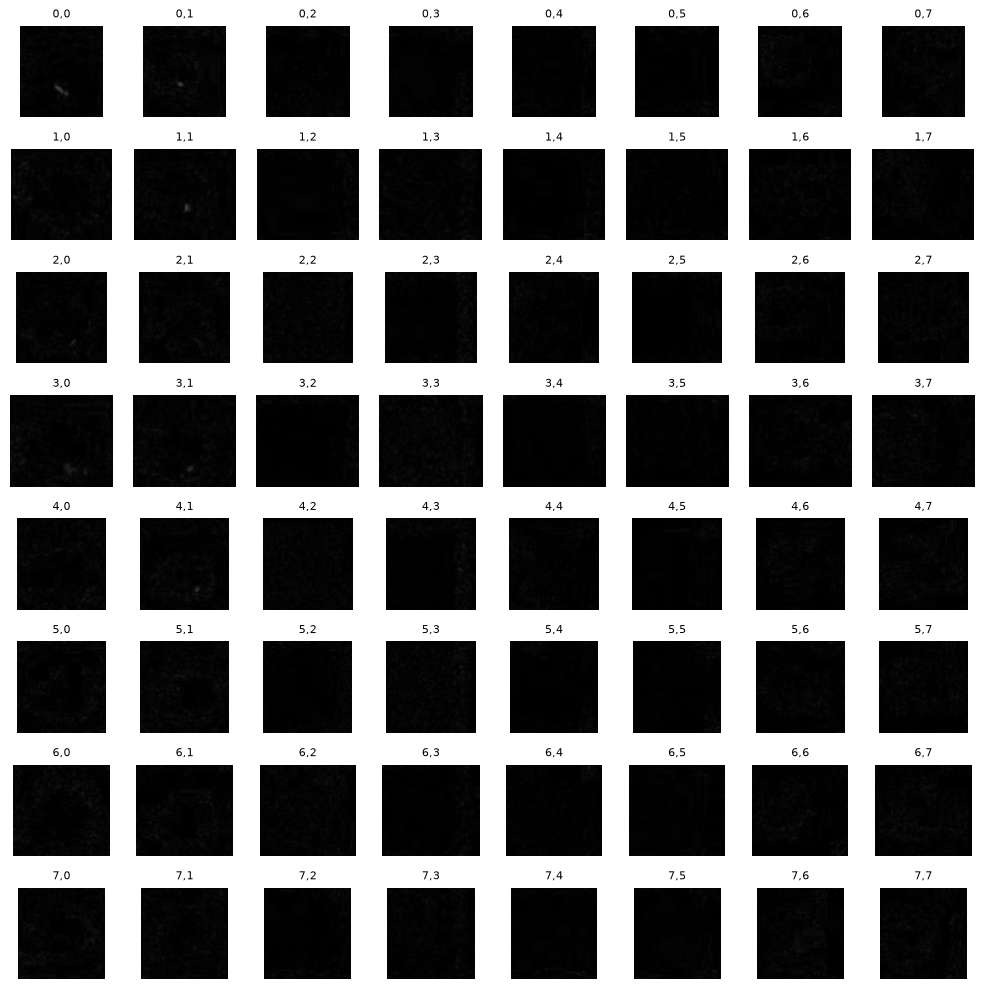

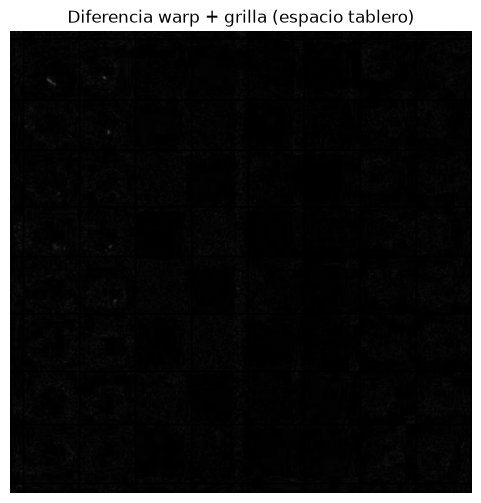


Turno actual: blanco

Orígenes candidatos: []
Destinos candidatos: []
No se pudo inferir movimiento
Referencia actualizada en 1000 ms (2 frames estables)
[[4 6]
 [4 4]]


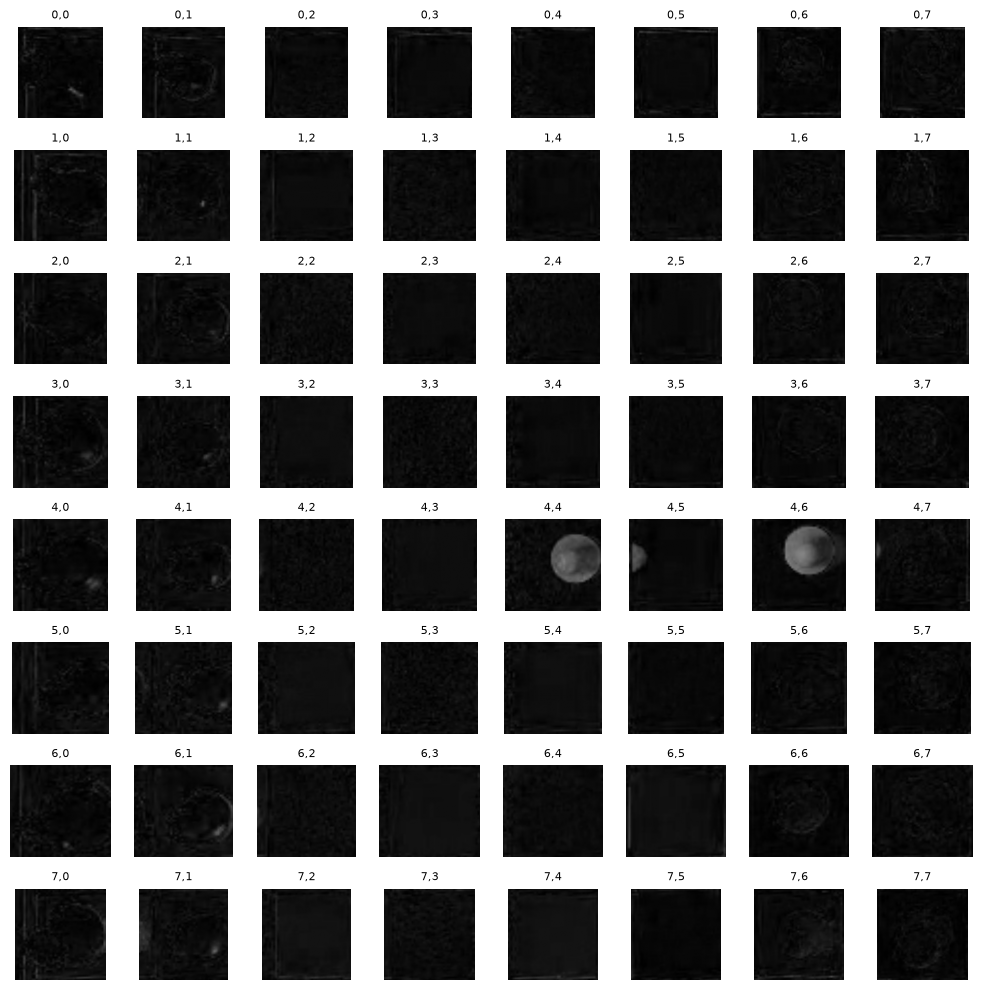

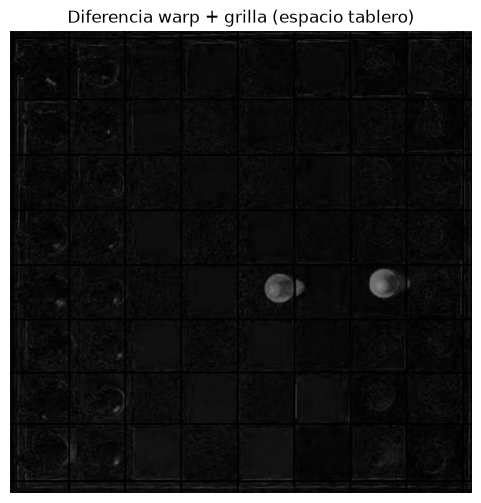


Turno actual: blanco

Orígenes candidatos: []
Destinos candidatos: [(np.int64(4), np.int64(6)), (np.int64(4), np.int64(4))]
No se pudo inferir movimiento
Referencia actualizada en 5000 ms (2 frames estables)
[]


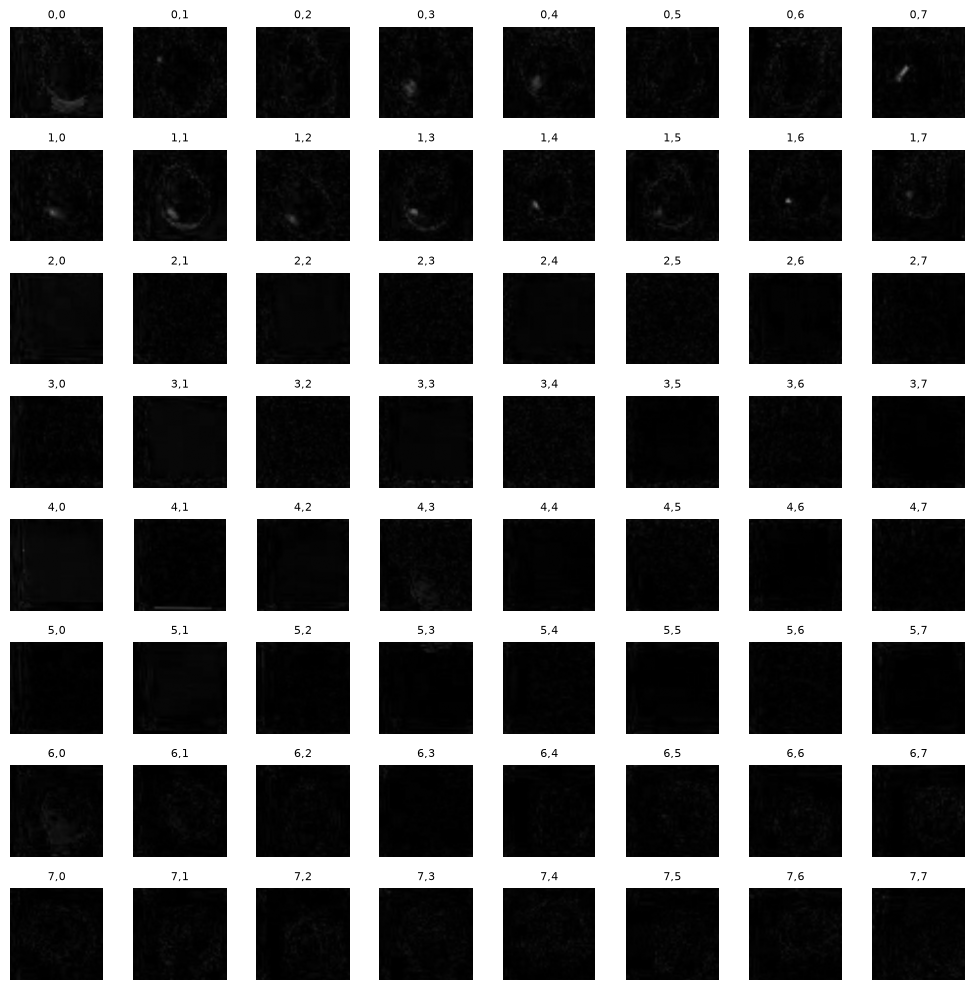

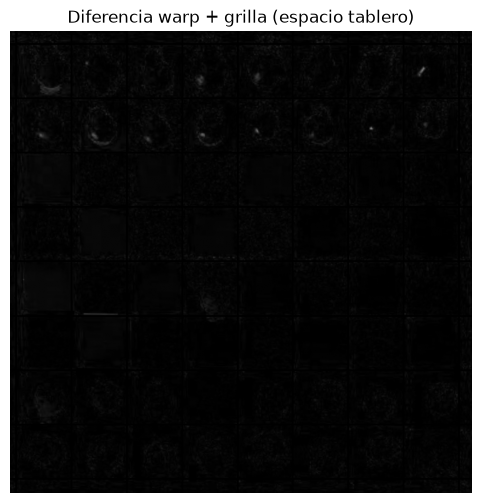


Turno actual: blanco

Orígenes candidatos: []
Destinos candidatos: []
No se pudo inferir movimiento
Referencia actualizada en 6000 ms (2 frames estables)
[[3 1]
 [3 3]]


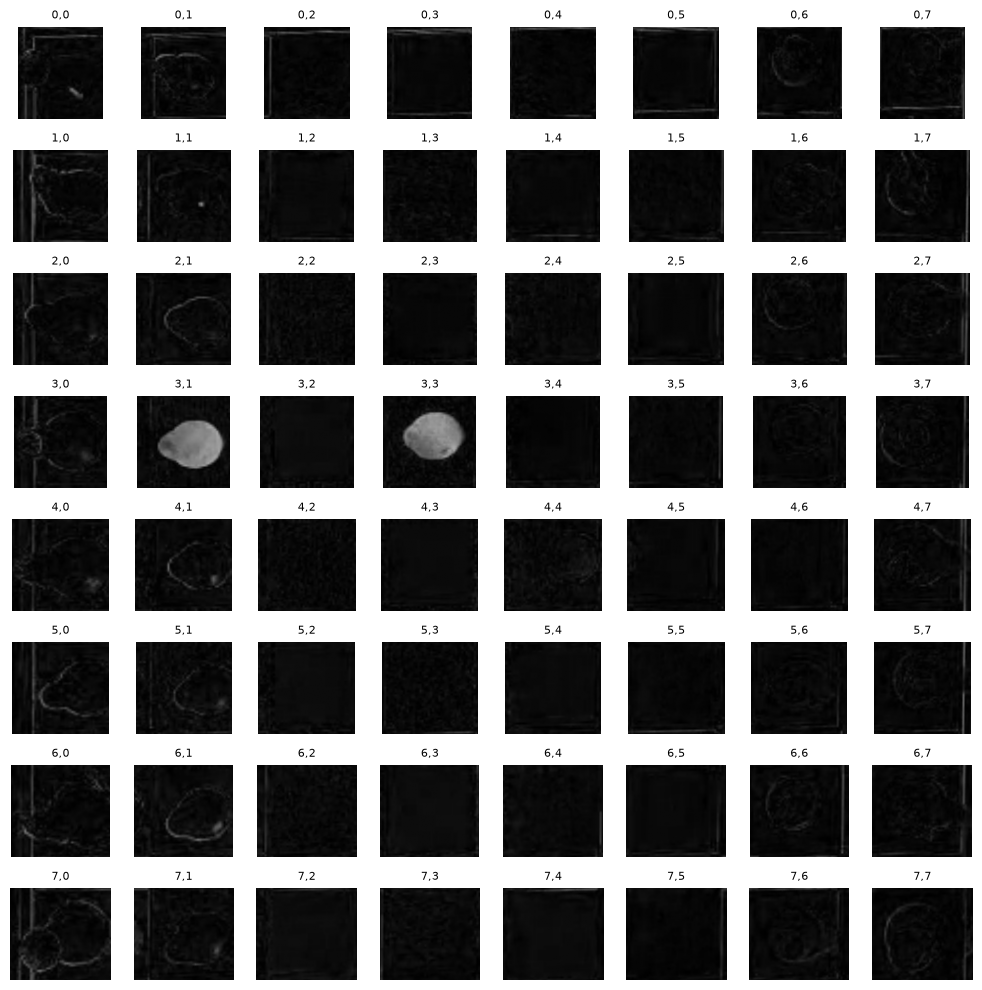

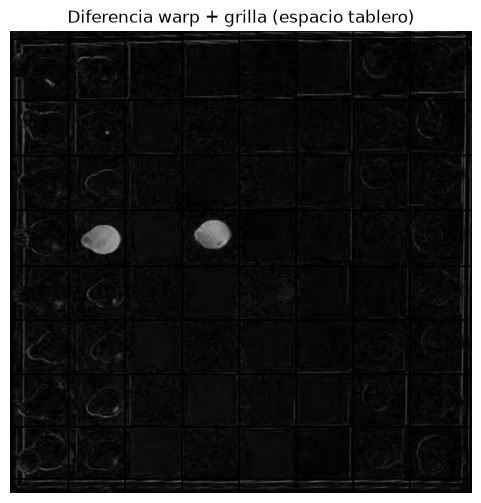


Turno actual: blanco

Orígenes candidatos: []
Destinos candidatos: [(np.int64(3), np.int64(1)), (np.int64(3), np.int64(3))]
No se pudo inferir movimiento
Referencia actualizada en 9000 ms (2 frames estables)
[[3 3]
 [4 4]]


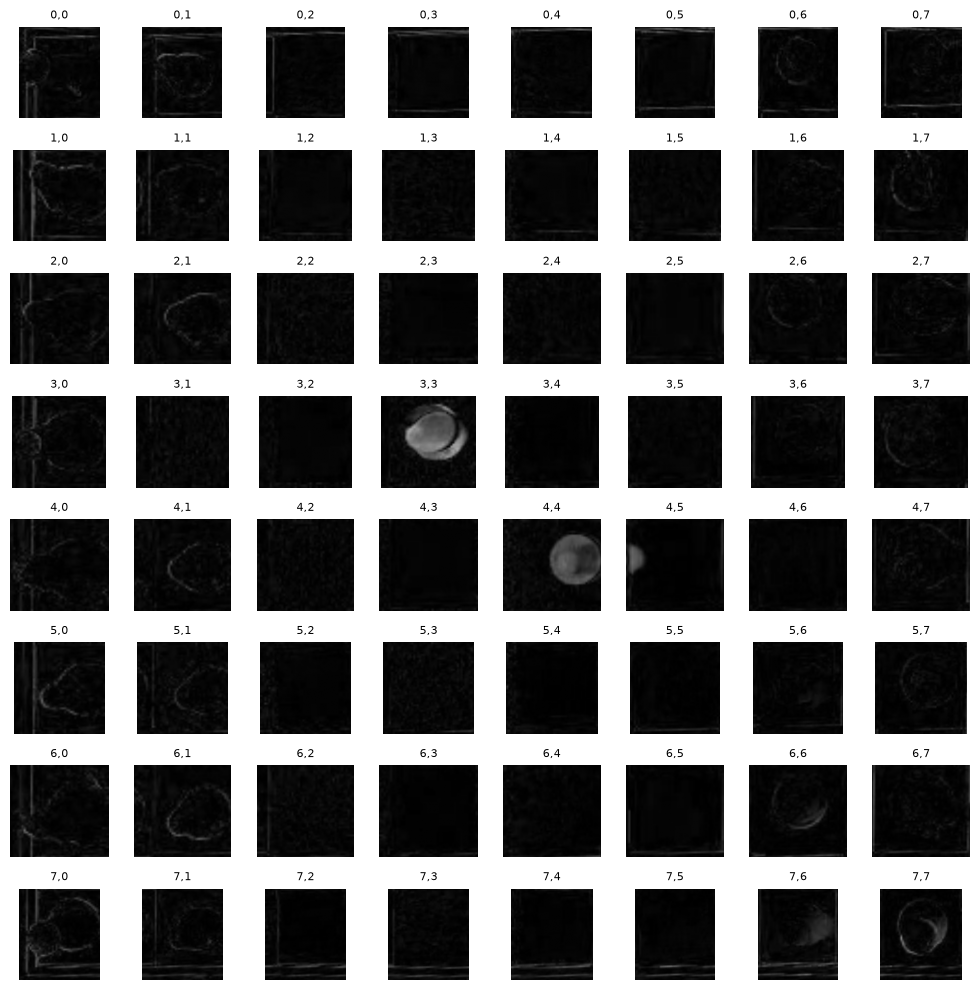

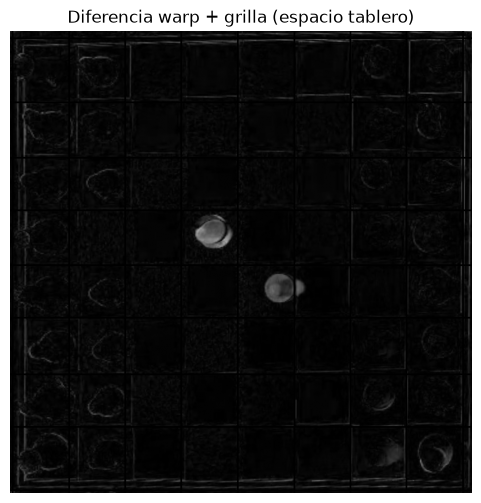


Turno actual: blanco

Orígenes candidatos: []
Destinos candidatos: [(np.int64(3), np.int64(3)), (np.int64(4), np.int64(4))]
No se pudo inferir movimiento
Referencia actualizada en 13500 ms (2 frames estables)
Torre(blanco) en [7,7] fue eliminado del tablero
Caballo(blanco) en [7,6] fue eliminado del tablero
Alfil(blanco) en [7,5] fue eliminado del tablero
Rey(blanco) en [7,4] fue eliminado del tablero
Reina(blanco) en [7,3] fue eliminado del tablero
Alfil(blanco) en [7,2] fue eliminado del tablero
Caballo(blanco) en [7,1] fue eliminado del tablero
Torre(blanco) en [7,0] fue eliminado del tablero
Peon(blanco) en [6,7] fue eliminado del tablero
Peon(blanco) en [6,6] fue eliminado del tablero
Peon(blanco) en [6,5] fue eliminado del tablero
Peon(blanco) en [6,4] fue eliminado del tablero
Peon(blanco) en [6,3] fue eliminado del tablero
Peon(blanco) en [6,2] fue eliminado del tablero
Peon(blanco) en [6,1] fue eliminado del tablero
Peon(blanco) en [6,0] fue eliminado del tablero
Peon(negro) 

In [12]:
# Previo a ejecutar la función, inicializar un tablero digital.
video, energias, interrupciones, referencias = ejecutar_foto_captura(
    vivo=False,
    ms=500,
    actualizar_ref_ms=200,
    N_estables=2,
    umbral=500,
    umbral_pieza=600)

In [13]:
ver_por_frame(video, energias, interrupciones, referencias)

In [14]:
# Para probar diferentes combinaciones del detector del tablero.
def ajustar_detector_tablero(imagen_gris):

    cv2.namedWindow("Controles")

    cv2.createTrackbar(
        "Blur",
        "Controles",
        5,
        31,
        lambda x: None
    )

    cv2.createTrackbar(
        "Canny Min",
        "Controles",
        50,
        500,
        lambda x: None
    )

    cv2.createTrackbar(
        "Canny Max",
        "Controles",
        150,
        500,
        lambda x: None
    )

    cv2.createTrackbar(
        "Kernel Close",
        "Controles",
        5,
        20,
        lambda x: None
    )

    while True:

        blur = cv2.getTrackbarPos(
            "Blur",
            "Controles"
        )

        canny_min = cv2.getTrackbarPos(
            "Canny Min",
            "Controles"
        )

        canny_max = cv2.getTrackbarPos(
            "Canny Max",
            "Controles"
        )

        kernel_size = cv2.getTrackbarPos(
            "Kernel Close",
            "Controles"
        )

        blur = max(1, blur)
        if blur % 2 == 0:
            blur += 1

        kernel_size = max(1, kernel_size)

        desenfocado = cv2.GaussianBlur(
            imagen_gris,
            (blur, blur),
            0
        )

        bordes = cv2.Canny(
            desenfocado,
            canny_min,
            canny_max
        )

        kernel = np.ones(
            (kernel_size, kernel_size),
            np.uint8
        )

        cerrada = cv2.morphologyEx(
            bordes,
            cv2.MORPH_CLOSE,
            kernel
        )

        contornos, _ = cv2.findContours(
            cerrada,
            cv2.RETR_EXTERNAL,
            cv2.CHAIN_APPROX_SIMPLE
        )

        imagen_contornos = cv2.cvtColor(
            imagen_gris,
            cv2.COLOR_GRAY2BGR
        )

        if len(contornos) > 0:

            contorno = max(
                contornos,
                key=cv2.contourArea
            )

            cv2.drawContours(
                imagen_contornos,
                [contorno],
                -1,
                (0, 255, 0),
                3
            )

            hull = cv2.convexHull(contorno)

            cv2.drawContours(
                imagen_contornos,
                [hull],
                -1,
                (255, 0, 0),
                2
            )

            perimetro = cv2.arcLength(
                hull,
                True
            )

            approx = cv2.approxPolyDP(
                hull,
                0.04 * perimetro,
                True
            )

            cv2.drawContours(
                imagen_contornos,
                [approx],
                -1,
                (0, 0, 255),
                4
            )

            for p in approx:

                x, y = p[0]

                cv2.circle(
                    imagen_contornos,
                    (x, y),
                    8,
                    (0, 255, 255),
                    -1
                )

        cv2.imshow(
            "Original",
            imagen_gris
        )

        cv2.imshow(
            "Blur",
            desenfocado
        )

        cv2.imshow(
            "Canny",
            bordes
        )

        cv2.imshow(
            "Cierre",
            cerrada
        )

        cv2.imshow(
            "Contorno Final",
            imagen_contornos
        )

        tecla = cv2.waitKey(30)

        if tecla == 27:  # ESC
            break

    cv2.destroyAllWindows()

#frame = video[0]
#gris = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

#ajustar_detector_tablero(gris)